In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [3]:
# Step 1: Folder path
folder_path = "/content/drive/MyDrive/dataset"

In [4]:
# Step 2: Read all CSV files
all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

dataframes = []

for file in all_files:
    path = os.path.join(folder_path, file)
    df = pd.read_csv(path)

    print(f"Loaded {file} → shape: {df.shape}")

    # Step 3: Standardize target column (moved from original cell b_7HF_qejyON)
    if 'bug' in df.columns:
        target = 'bug'
    elif 'defects' in df.columns:
        target = 'defects'
    elif 'label' in df.columns:
        target = 'label'
    else:
        print(f"Skipping {file} (no target column)")
        continue

    df[target] = df[target].apply(lambda x: 1 if x > 0 else 0)
    df = df.rename(columns={target: 'target'})

    dataframes.append(df)

Loaded ant-1.7 (1).csv → shape: (745, 21)
Loaded camel-1.0.csv → shape: (339, 21)
Loaded camel-1.6 (1).csv → shape: (965, 22)
Loaded data_arc (1).csv → shape: (225, 21)
Loaded data_ivy-2.0 (1).csv → shape: (352, 21)
Loaded data_prop-6 (1).csv → shape: (644, 21)
Loaded data_redaktor (1).csv → shape: (175, 21)
Loaded jedit-3.2.csv → shape: (272, 21)
Loaded jedit-4.2.csv → shape: (367, 21)
Loaded log4j-1.1.csv → shape: (109, 21)
Loaded lucene-2.0.csv → shape: (195, 21)
Loaded poi-2.0.csv → shape: (314, 21)
Loaded synapse-1.0.csv → shape: (157, 22)
Loaded synapse-1.2.csv → shape: (256, 21)
Loaded velocity-1.6.csv → shape: (229, 21)
Loaded xalan-2.4.csv → shape: (723, 21)
Loaded xerces-1.2.csv → shape: (440, 22)
Loaded xerces-1.3.csv → shape: (453, 21)


In [5]:
# Step 4: Combine all datasets
final_df = pd.concat(dataframes, ignore_index=True, join='outer')

# Keep only numeric columns
final_df = final_df.select_dtypes(include=np.number)

if 'target' not in final_df.columns:
    raise ValueError("'target' column not found.")

print("Final dataset shape:", final_df.shape)

Final dataset shape: (6960, 22)


In [6]:
# Step 5: Handle missing values
final_df = final_df.fillna(final_df.mean())

In [7]:
# Step 6: Split features and target
X = final_df.drop(columns=['target'])
y = final_df['target']

In [8]:
# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# Step 8: Apply SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train).value_counts())


After SMOTE:
 target
1    4564
0    4564
Name: count, dtype: int64


In [10]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adb = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner (stump)
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

adb.fit(X_train, y_train)
y_pred = adb.predict(X_test)

In [11]:
# Step 10: Predictions
y_pred = adb.predict(X_test)
y_scores = adb.predict_proba(X_test)[:, 1]


In [12]:
# Step 11: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7212643678160919

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.53      0.41       251
           1       0.88      0.76      0.82      1141

    accuracy                           0.72      1392
   macro avg       0.61      0.65      0.61      1392
weighted avg       0.78      0.72      0.74      1392

Confusion Matrix:
 [[133 118]
 [270 871]]


### Confusion Matrix

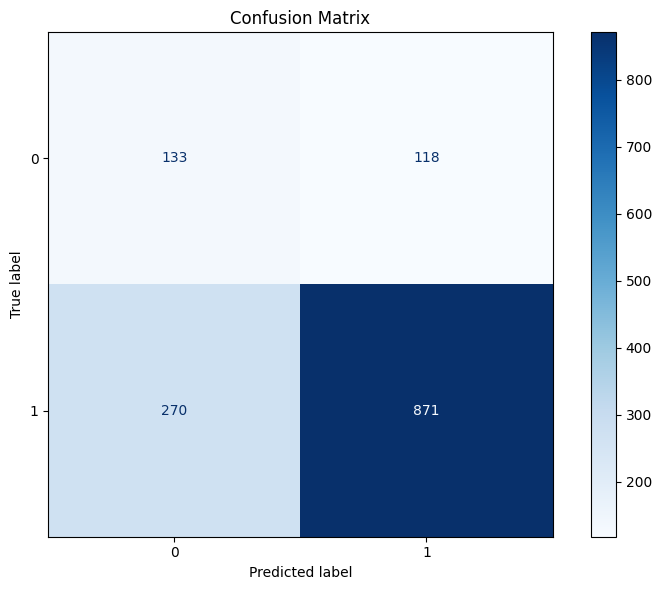

In [13]:
import matplotlib.pyplot as plt

# Plot Confusion Matrix
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(adb, X_test, y_test, cmap=plt.cm.Blues, ax=ax_cm)
ax_cm.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Precision-Recall Curve

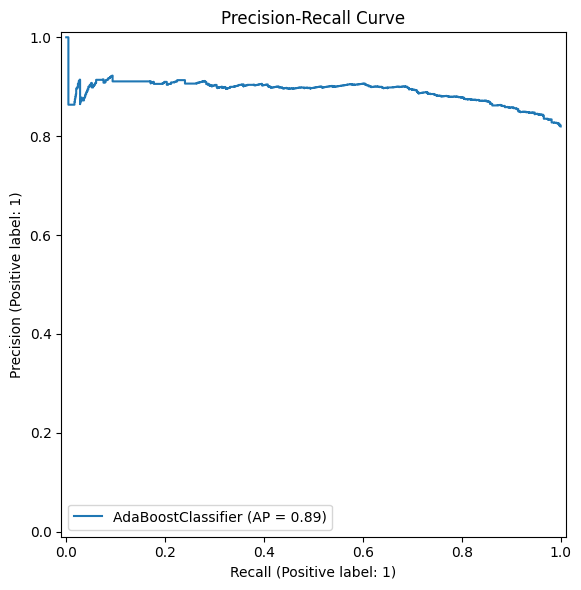

In [14]:
import matplotlib.pyplot as plt

# Plot Precision-Recall Curve
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(adb, X_test, y_test, ax=ax_pr)
ax_pr.set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

### ROC Curve

In [15]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.53      0.41       251
           1       0.88      0.76      0.82      1141

    accuracy                           0.72      1392
   macro avg       0.61      0.65      0.61      1392
weighted avg       0.78      0.72      0.74      1392



In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score, accuracy_score

# Calculate precision, recall, and f1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate Cohen's Kappa coefficient
kappa = cohen_kappa_score(y_test, y_pred)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Precision: 0.8807
Recall: 0.7634
F1-score: 0.8178
Cohen's Kappa: 0.2372
Accuracy: 0.7213


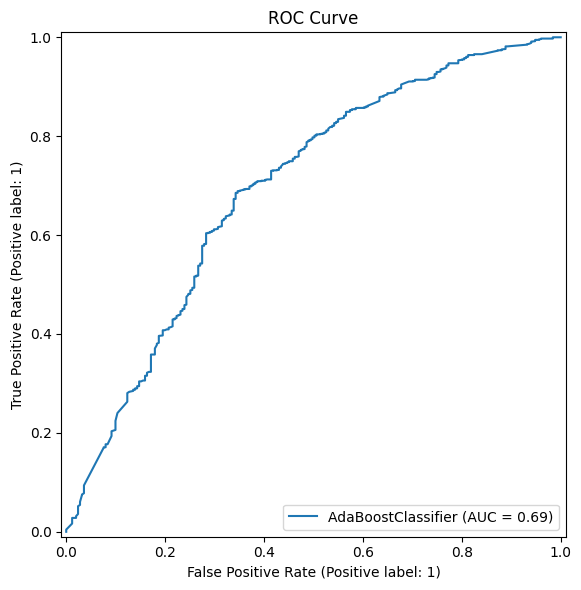

In [17]:
import matplotlib.pyplot as plt

# Plot ROC Curve
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(adb, X_test, y_test, ax=ax_roc)
ax_roc.set_title('ROC Curve')
plt.tight_layout()
plt.show()